In [1]:
#comparision and evaluation of clustering algorithms

#importing requried libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

In [2]:
#generate dataset
x, _=make_moons(n_samples=300, noise=0.08, random_state=42)

In [3]:
#scale data
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [5]:
#apply clustering algorithms
km=KMeans(n_clusters=2, random_state=42)
klabels=km.fit_predict(x_scaled)

dbscan=DBSCAN(eps=0.3, min_samples=5)
dblabels=dbscan.fit_predict(x_scaled)

agg=AgglomerativeClustering(n_clusters=2)
aglabels=agg.fit_predict(x_scaled)

In [10]:
#define evaluation function
def evaluate_clustering(x, labels, name):
    if -1 in labels:
        mask=labels!=-1
        x=x[mask]
        labels=labels[mask]

    print(f"\n{name} evaluation metrics:")
    print(f"Silhouette Score: ", silhouette_score(x, labels))
    print(f"Davies-Bouldin Score:",davies_bouldin_score(x, labels))

evaluate_clustering(x_scaled, klabels, "K-Means")
evaluate_clustering(x_scaled, dblabels, "DBSCAN")
evaluate_clustering(x_scaled, aglabels, "Agglomerative Clustering")



K-Means evaluation metrics:
Silhouette Score:  0.49363038566825634
Davies-Bouldin Score: 0.8055676885980051

DBSCAN evaluation metrics:
Silhouette Score:  0.38025084295785
Davies-Bouldin Score: 1.0252181966774392

Agglomerative Clustering evaluation metrics:
Silhouette Score:  0.45226772209813776
Davies-Bouldin Score: 0.8640447998820315


Text(0.5, 1.0, 'Agglomerative Clustering')

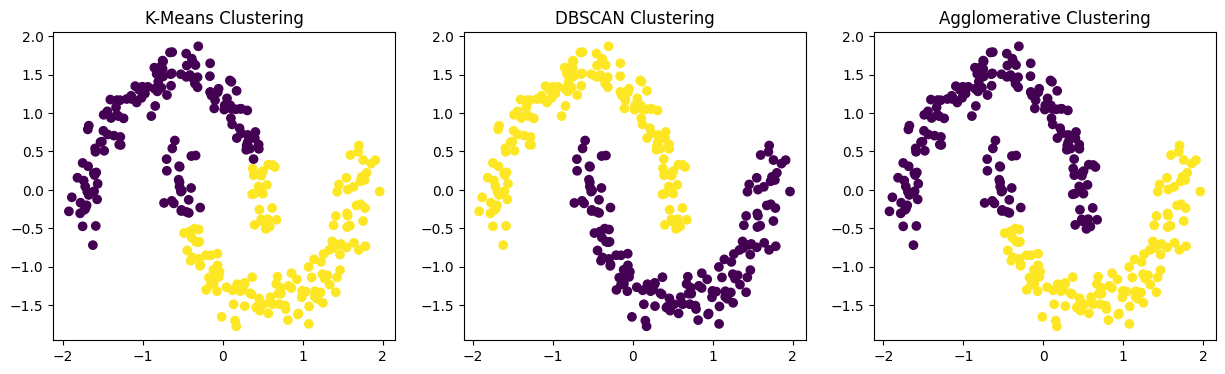

In [11]:
#plot results
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=klabels)
plt.title("K-Means Clustering")

plt.subplot(1,3,2)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=dblabels)
plt.title("DBSCAN Clustering")

plt.subplot(1,3,3)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=aglabels)
plt.title("Agglomerative Clustering")